In [1]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
final_model = joblib.load("../models/final_model.pkl")

In [3]:
df = pd.read_csv("../data/processed/feature_engineered.csv")

X = df.drop("Churn", axis=1)
y = df["Churn"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    random_state=42,
    test_size=0.2
)

# Predictions

In [5]:
y_pred = final_model.predict(X_test)

y_prob = final_model.predict_proba(X_test)[:,1]

# Confusion Matrix

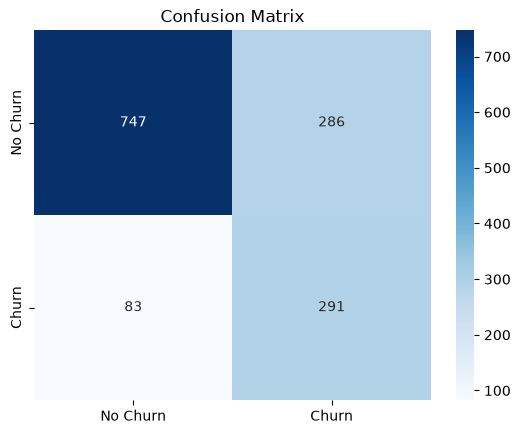

In [6]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.title("Confusion Matrix")
plt.show()

# Classification Report

In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.75      1407



# False Positives

In [8]:
false_positive_idx = (
    (y_test == 0) &
    (y_pred == 1)
)

false_positives = X_test[false_positive_idx]

false_positives.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TotalCharges,TenureGroup,AvgMonthlySpend,IsNewCustomer,LongTermContract,TotalServices,SecurityBundle,StreamingUser,AutoPayment,PremiumCustomer
618,Female,0,No,No,7,Yes,Yes,Fiber optic,No,Yes,...,522.95,0-1 Year,74.707143,1,0,3,0,0,1,1
4276,Male,1,Yes,No,4,Yes,No,Fiber optic,No,No,...,280.35,0-1 Year,70.087500,1,0,1,0,0,0,0
6119,Female,0,Yes,No,14,Yes,No,Fiber optic,No,No,...,1122.40,1-2 Years,80.171429,0,0,2,0,1,0,1
3929,Male,0,No,No,9,Yes,No,DSL,Yes,No,...,576.95,0-1 Year,64.105556,1,0,5,1,1,1,0
5375,Female,0,No,No,4,Yes,Yes,DSL,No,No,...,253.00,0-1 Year,63.250000,1,0,4,0,1,0,0


# False Negatives

In [9]:
false_negative_idx = (
    (y_test == 1) &
    (y_pred == 0)
)

false_negatives = X_test[false_negative_idx]

false_negatives.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TotalCharges,TenureGroup,AvgMonthlySpend,IsNewCustomer,LongTermContract,TotalServices,SecurityBundle,StreamingUser,AutoPayment,PremiumCustomer
3715,Female,0,No,No,2,Yes,No,No,No internet service,No internet service,...,38.70,0-1 Year,19.350000,1,0,1,0,0,0,0
4645,Female,0,Yes,Yes,30,No,No phone service,DSL,No,No,...,1561.50,2-4 Years,52.050000,0,0,3,0,1,1,0
2295,Female,0,Yes,Yes,48,Yes,Yes,Fiber optic,Yes,Yes,...,5037.55,2-4 Years,104.948958,0,1,6,0,1,1,1
5729,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,...,20.60,0-1 Year,20.600000,1,0,1,0,0,0,0
18,Female,0,Yes,Yes,10,Yes,No,DSL,No,No,...,528.35,0-1 Year,52.835000,1,0,3,0,0,1,0


In [15]:
print(f"False Positives: {len(false_positives)}")
print(f"False Negatives: {len(false_negatives)}")

False Positives: 286
False Negatives: 83


In [16]:
false_positives.describe()
false_negatives.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend,IsNewCustomer,LongTermContract,TotalServices,SecurityBundle,StreamingUser,AutoPayment,PremiumCustomer
count,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000
mean,0.096386,30.831325,64.675301,2477.906627,64.258079,0.289157,0.493976,3.590361,0.180723,0.542169,0.457831,0.397590
std,0.296913,22.544709,30.152339,2284.669986,30.067081,0.456127,0.503003,1.969500,0.387128,0.501247,0.501247,0.492375
min,0.000000,1.000000,18.950000,19.400000,14.150000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,8.500000,49.150000,232.325000,46.532212,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,32.000000,61.650000,2088.750000,61.231522,0.000000,0.000000,3.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,48.500000,91.575000,4015.800000,90.680346,1.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,68.000000,113.150000,7856.000000,115.529412,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
thresholds = np.arange(
    0.1,
    0.91,
    0.05
)
threshold_results = []

In [12]:
for threshold in thresholds:

    predictions = (
        y_prob >= threshold
    ).astype(int)

    threshold_results.append({

        "Threshold": threshold,

        "Precision": precision_score(
            y_test,
            predictions
        ),

        "Recall": recall_score(
            y_test,
            predictions
        ),

        "F1": f1_score(
            y_test,
            predictions
        )

    })

In [13]:
threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.352546,0.981283,0.518728
1,0.15,0.377101,0.959893,0.541478
2,0.20,0.395323,0.949198,0.558176
3,0.25,0.411072,0.933155,0.570728
4,0.30,0.427854,0.911765,0.582408
5,0.35,0.440108,0.874332,0.585497
6,0.40,0.458453,0.855615,0.597015
7,0.45,0.481013,0.812834,0.604374
8,0.50,0.504333,0.778075,0.611987
9,0.55,0.522073,0.727273,0.607821


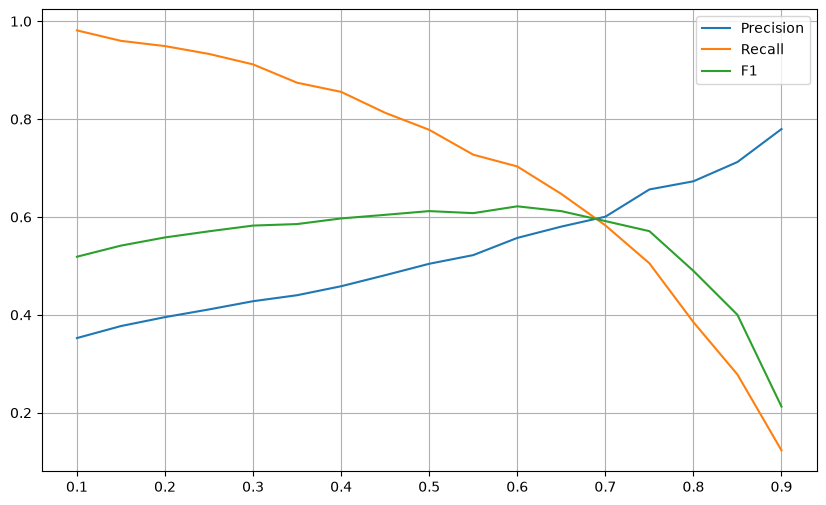

In [14]:
plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1"
)

plt.legend()

plt.grid()

plt.show()

# Summary

Objective

Evaluate the prediction errors of the final customer churn model and understand their business implications through confusion matrix analysis, misclassification analysis, and threshold evaluation.

Key Findings
The model successfully identified approximately 78% of actual churners, making it effective for customer retention initiatives.
False Positives mainly consisted of customers who exhibited characteristics similar to churners, suggesting that the model appropriately classified borderline cases.
False Negatives represented missed retention opportunities and remain the most significant source of business risk.
Threshold analysis demonstrated the expected trade-off between Precision and Recall, with lower thresholds increasing customer coverage while also increasing false alarms.
The default decision threshold of 0.50 achieved the highest F1-score and provided the best compromise between identifying churners and limiting unnecessary retention actions.
Conclusion

The error analysis confirms that the selected SMOTE Logistic Regression model is well suited for customer churn prediction. Rather than focusing solely on overall accuracy, the analysis highlights the practical business implications of different prediction errors and decision thresholds. These insights enable organizations to deploy the model in a manner that aligns with their retention strategy, campaign budget, and tolerance for prediction errors.